# Lab Problem Statement 6: Customer Segmentation and Predictive Analytics Using Machine Learning

**Problem statement:** Using the UCI Online Retail dataset, build customer-level features (RFM etc.), segment customers with K-Means and Hierarchical Clustering, validate with Silhouette Score, visualise with PCA and Plotly 3D, profile segments, predict a high-value segment with Random Forest and SVM, and recommend marketing strategies.

**Dataset:** UCI Online Retail (541,909 transactions: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country).


## 1. Setup and Data Loading

In [22]:
pkgs <- c("readxl", "dplyr", "tidyr", "ggplot2", "factoextra", "cluster",
          "randomForest", "e1071", "pROC", "plotly", "mclust", "reshape2")
new <- pkgs[!(pkgs %in% rownames(installed.packages()))]
if (length(new)) install.packages(new, repos = "https://cloud.r-project.org", quiet = TRUE)

suppressPackageStartupMessages({
  library(readxl); library(dplyr); library(tidyr); library(ggplot2)
  library(factoextra); library(cluster); library(randomForest); library(e1071)
  library(pROC); library(plotly); library(mclust); library(reshape2)
})
options(repr.plot.width = 9, repr.plot.height = 5)
set.seed(42)

In [23]:
url  <- "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
zipf <- "online_retail.zip"
ok <- tryCatch({ download.file(url, zipf, mode = "wb", quiet = TRUE); TRUE },
               error = function(e) FALSE, warning = function(w) FALSE)
if (ok) unzip(zipf, exdir = "online_retail")
path <- "online_retail/Online Retail.xlsx"

# If the download failed: download the dataset manually from UCI, upload it via the
# Colab Files sidebar, and set  path <- "Online Retail.xlsx"
stopifnot(file.exists(path))

raw <- read_excel(path)
cat("Dimensions:", dim(raw), "\n")
head(raw)

Dimensions: 541909 8 


InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom


In [ ]:
str(raw)
colSums(is.na(raw))
summary(raw[, c("Quantity", "UnitPrice")])

tibble [541,909 × 8] (S3: tbl_df/tbl/data.frame)
 $ InvoiceNo  : chr [1:541909] "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr [1:541909] "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr [1:541909] "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : num [1:541909] 6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: POSIXct[1:541909], format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 $ UnitPrice  : num [1:541909] 2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : num [1:541909] 17850 17850 17850 17850 17850 ...
 $ Country    : chr [1:541909] "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...


InvoiceNo   StockCode Description    Quantity InvoiceDate   UnitPrice 
          0           0        1454           0           0           0 
 CustomerID     Country 
     135080           0

    Quantity            UnitPrice         
 Min.   :-80995.000   Min.   :-11062.060  
 1st Qu.:     1.000   1st Qu.:     1.250  
 Median :     3.000   Median :     2.080  
 Mean   :     9.552   Mean   :     4.611  
 3rd Qu.:    10.000   3rd Qu.:     4.130  
 Max.   : 80995.000   Max.   : 38970.000  

## 2. Data Preprocessing

In [ ]:
df <- raw %>%
  mutate(InvoiceNo = as.character(InvoiceNo),
         IsCancel  = startsWith(InvoiceNo, "C"))

# Keep cancellation counts per customer before removing cancellations
cancel_counts <- df %>%
  filter(IsCancel, !is.na(CustomerID)) %>%
  group_by(CustomerID) %>%
  summarise(Cancellations = n_distinct(InvoiceNo), .groups = "drop")

n0 <- nrow(df)
clean <- df %>%
  filter(!is.na(CustomerID),          # missing customer IDs
         !IsCancel,                   # cancellations
         Quantity > 0, UnitPrice > 0) %>%   # returns / free / adjustment rows
  distinct() %>%
  mutate(CustomerID = as.integer(CustomerID),
         TotalPrice = Quantity * UnitPrice)

cat(sprintf("Rows: %s -> %s after cleaning | Customers: %s\n",
            format(n0, big.mark = ","), format(nrow(clean), big.mark = ","),
            format(n_distinct(clean$CustomerID), big.mark = ",")))

Rows: 541,909 -> 392,692 after cleaning | Customers: 4,338


## 3. Customer-level Feature Engineering

In [ ]:
snapshot <- as.Date(max(clean$InvoiceDate)) + 1

cust <- clean %>%
  group_by(CustomerID) %>%
  summarise(
    Recency        = as.numeric(snapshot - as.Date(max(InvoiceDate))),
    Frequency      = n_distinct(InvoiceNo),
    Monetary       = sum(TotalPrice),
    TotalQuantity  = sum(Quantity),
    UniqueProducts = n_distinct(StockCode),
    TenureDays     = as.numeric(as.Date(max(InvoiceDate)) - as.Date(min(InvoiceDate))) + 1,
    .groups = "drop") %>%
  mutate(AvgTransactionValue = Monetary / Frequency,
         AvgBasketQty        = TotalQuantity / Frequency,
         PurchaseFrequency   = Frequency / pmax(TenureDays / 30, 1)) %>%   # orders per active month
  left_join(cancel_counts, by = "CustomerID") %>%
  mutate(Cancellations = replace_na(Cancellations, 0),
         CancelRate    = Cancellations / (Frequency + Cancellations))

dim(cust)
summary(cust)

[1] 4338   12

   CustomerID       Recency         Frequency          Monetary        
 Min.   :12346   Min.   :  1.00   Min.   :  1.000   Min.   :     3.75  
 1st Qu.:13813   1st Qu.: 18.00   1st Qu.:  1.000   1st Qu.:   306.48  
 Median :15300   Median : 51.00   Median :  2.000   Median :   668.57  
 Mean   :15300   Mean   : 93.06   Mean   :  4.272   Mean   :  2048.69  
 3rd Qu.:16779   3rd Qu.:142.75   3rd Qu.:  5.000   3rd Qu.:  1660.60  
 Max.   :18287   Max.   :374.00   Max.   :209.000   Max.   :280206.02  
 TotalQuantity      UniqueProducts     TenureDays    AvgTransactionValue
 Min.   :     1.0   Min.   :   1.0   Min.   :  1.0   Min.   :    3.45   
 1st Qu.:   159.0   1st Qu.:  16.0   1st Qu.:  1.0   1st Qu.:  177.87   
 Median :   378.0   Median :  35.0   Median : 94.0   Median :  291.94   
 Mean   :  1187.6   Mean   :  61.5   Mean   :131.8   Mean   :  417.65   
 3rd Qu.:   989.8   3rd Qu.:  77.0   3rd Qu.:253.0   3rd Qu.:  428.28   
 Max.   :196915.0   Max.   :1787.0   Max.   :374.0   Max. 

## 4. Outlier Treatment and Feature Scaling

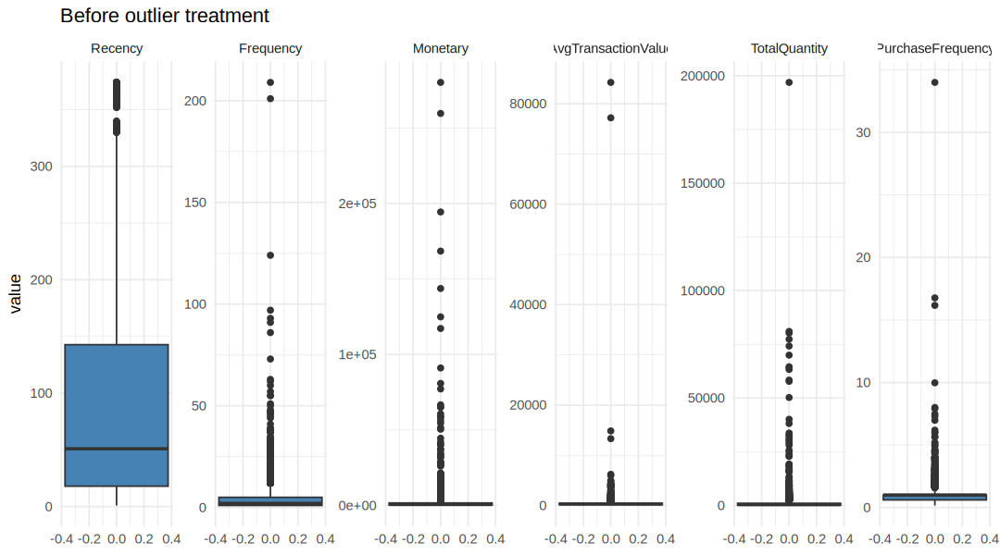

In [ ]:
cluster_features <- c("Recency", "Frequency", "Monetary", "AvgTransactionValue",
                      "TotalQuantity", "PurchaseFrequency")

# Boxplots before treatment
melt(cust[, cluster_features], measure.vars = cluster_features) %>%
  ggplot(aes(y = value)) + geom_boxplot(fill = "steelblue") +
  facet_wrap(~variable, scales = "free", nrow = 1) +
  labs(title = "Before outlier treatment") + theme_minimal()

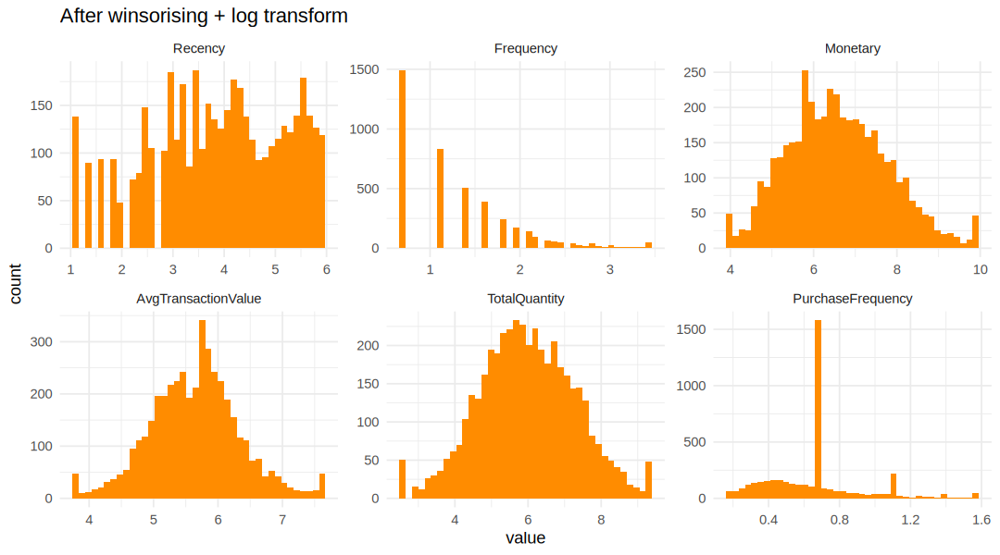

In [ ]:
winsorise <- function(x, p = c(0.01, 0.99)) {
  q <- quantile(x, p, na.rm = TRUE)
  pmin(pmax(x, q[1]), q[2])
}

X <- cust[, cluster_features] %>% mutate(across(everything(), winsorise))  # 1) cap outliers
X_log <- log1p(X)                                                          # 2) reduce skew
X_scaled <- scale(X_log)                                                   # 3) standardise
rownames(X_scaled) <- cust$CustomerID

melt(as.data.frame(X_log), measure.vars = cluster_features) %>%
  ggplot(aes(value)) + geom_histogram(bins = 40, fill = "darkorange") +
  facet_wrap(~variable, scales = "free") +
  labs(title = "After winsorising + log transform") + theme_minimal()

## 5. K-Means: Elbow Method and Silhouette Analysis

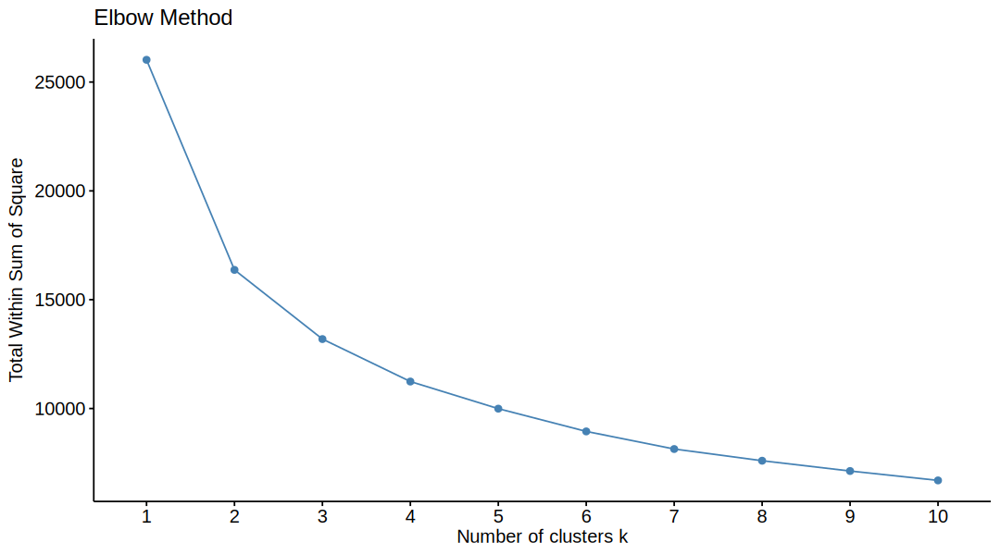

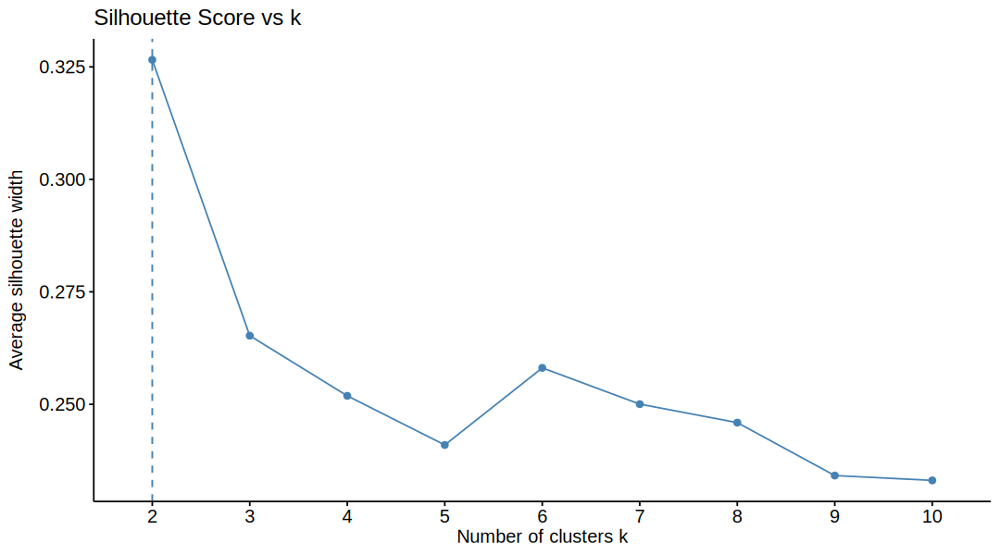

In [ ]:
p1 <- fviz_nbclust(X_scaled, kmeans, method = "wss", k.max = 10, nstart = 25) +
  labs(title = "Elbow Method")
p2 <- fviz_nbclust(X_scaled, kmeans, method = "silhouette", k.max = 10, nstart = 25) +
  labs(title = "Silhouette Score vs k")
print(p1); print(p2)

In [ ]:
# Choose k from the elbow plot (and silhouette). Edit if the elbow suggests otherwise.
K <- 4

set.seed(42)
km <- kmeans(X_scaled, centers = K, nstart = 25, iter.max = 100)
cust$KMeans_Cluster <- km$cluster

dist_mat <- dist(X_scaled)
sil_km <- mean(silhouette(km$cluster, dist_mat)[, 3])
cat("K-Means Silhouette:", round(sil_km, 4), "\n")
table(cust$KMeans_Cluster)

K-Means Silhouette: 0.2519 



   1    2    3    4 
1102 1144  698 1394 

## 6. Hierarchical Clustering and Dendrogram

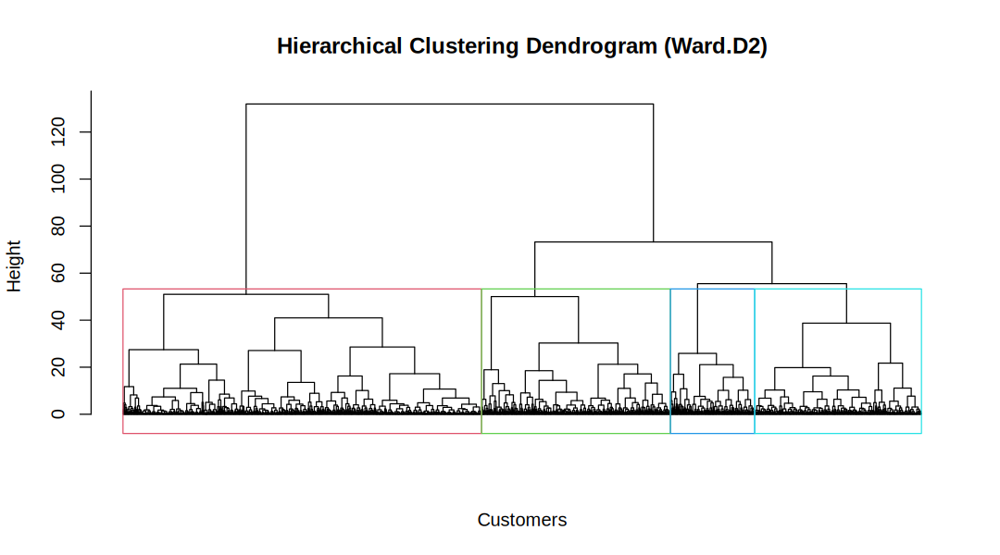

In [ ]:
hc <- hclust(dist_mat, method = "ward.D2")

plot(hc, labels = FALSE, hang = -1, main = "Hierarchical Clustering Dendrogram (Ward.D2)",
     xlab = "Customers", sub = "")
rect.hclust(hc, k = K, border = 2:(K + 1))

In [ ]:
cust$Hier_Cluster <- cutree(hc, k = K)

sil_hc <- mean(silhouette(cust$Hier_Cluster, dist_mat)[, 3])
ari    <- adjustedRandIndex(cust$KMeans_Cluster, cust$Hier_Cluster)

print(data.frame(Method = c("K-Means", "Hierarchical (Ward)"),
                 Silhouette = round(c(sil_km, sil_hc), 4)))
cat("Adjusted Rand Index (agreement between the two):", round(ari, 4), "\n")
table(KMeans = cust$KMeans_Cluster, Hierarchical = cust$Hier_Cluster)

               Method Silhouette
1             K-Means     0.2519
2 Hierarchical (Ward)     0.2107
Adjusted Rand Index (agreement between the two): 0.3153 


      Hierarchical
KMeans    1    2    3    4
     1    0    0 1084   18
     2  230    0  620  294
     3    4  616    0   78
     4  672  410  244   68

## 7. PCA: 2D Visualisation of Segments

Importance of components:
                          PC1    PC2    PC3     PC4     PC5     PC6
Standard deviation     1.8402 1.0438 0.9706 0.68730 0.32161 0.07797
Proportion of Variance 0.5644 0.1816 0.1570 0.07873 0.01724 0.00101
Cumulative Proportion  0.5644 0.7460 0.9030 0.98175 0.99899 1.00000

Variance explained by PC1+PC2: 0.746 


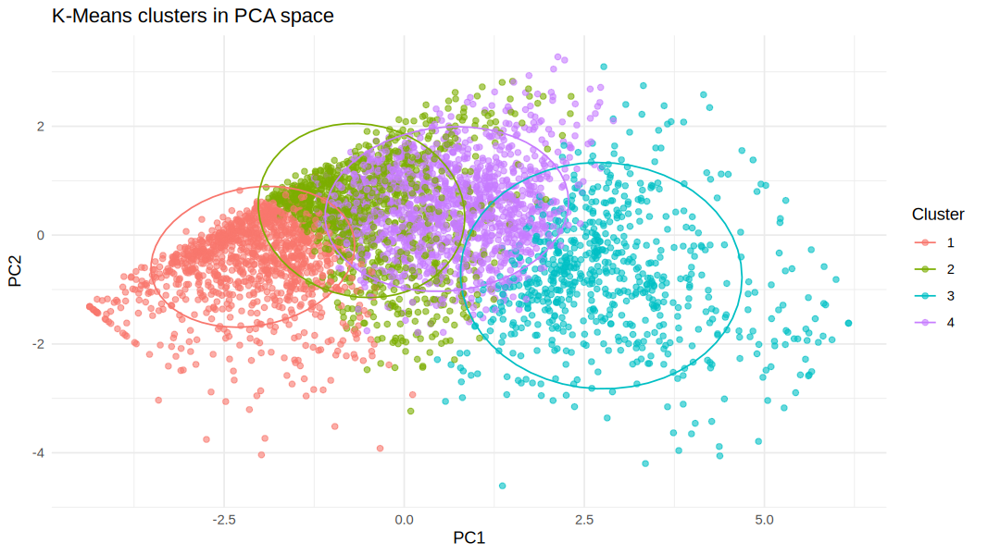

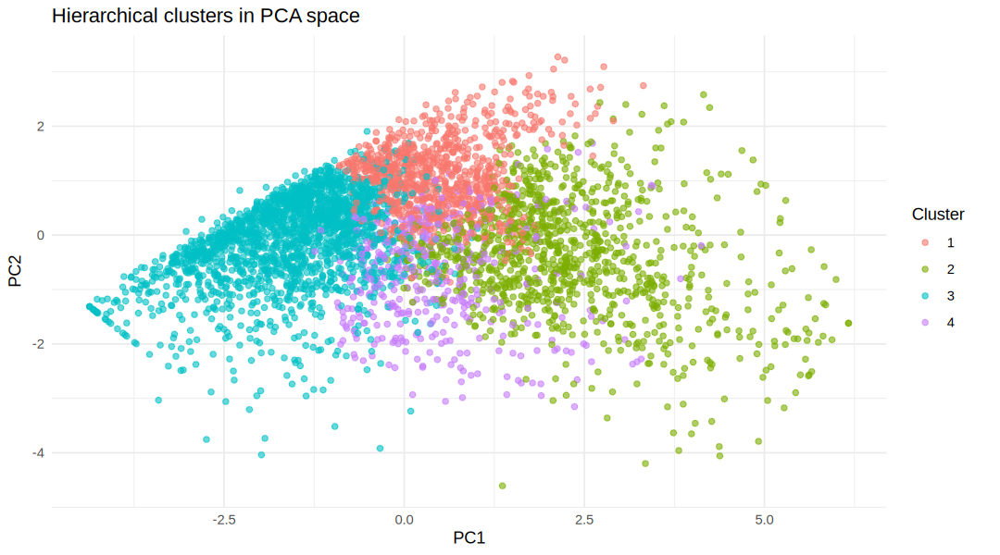

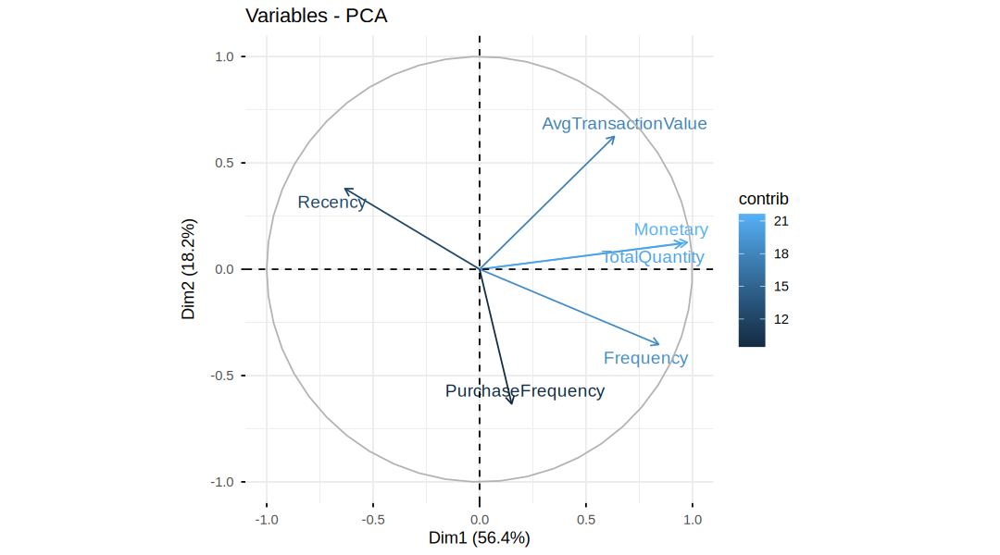

In [ ]:
pca <- prcomp(X_scaled, center = FALSE, scale. = FALSE)   # data already scaled
summary(pca)
cat("Variance explained by PC1+PC2:",
    round(sum(pca$sdev[1:2]^2) / sum(pca$sdev^2), 3), "\n")

cust$PC1 <- pca$x[, 1]; cust$PC2 <- pca$x[, 2]

ggplot(cust, aes(PC1, PC2, colour = factor(KMeans_Cluster))) +
  geom_point(alpha = 0.6, size = 1.5) +
  stat_ellipse(level = 0.9) +
  labs(title = "K-Means clusters in PCA space", colour = "Cluster") + theme_minimal()

ggplot(cust, aes(PC1, PC2, colour = factor(Hier_Cluster))) +
  geom_point(alpha = 0.6, size = 1.5) +
  labs(title = "Hierarchical clusters in PCA space", colour = "Cluster") + theme_minimal()

fviz_pca_var(pca, col.var = "contrib", repel = TRUE)   # feature loadings

## 8. Cluster Profiling

In [ ]:
profile <- cust %>%
  group_by(KMeans_Cluster) %>%
  summarise(across(c(all_of(cluster_features), UniqueProducts, CancelRate), ~ round(mean(.x), 2)),
            Customers = n(), Revenue = sum(Monetary), .groups = "drop") %>%
  mutate(`% Customers` = round(Customers / sum(Customers) * 100, 1),
         `% Revenue`   = round(Revenue / sum(Revenue) * 100, 1)) %>%
  select(-Revenue)
as.data.frame(profile)

KMeans_Cluster,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity,PurchaseFrequency,UniqueProducts,CancelRate,Customers,% Customers,% Revenue
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,153.73,1.47,193.74,142.91,110.16,1.03,17.11,0.05,1102,25.4,1.8
2,134.59,1.53,711.91,508.28,400.76,1.23,36.38,0.11,1144,26.4,6.6
3,20.30,13.74,8540.83,811.96,4894.65,1.70,154.71,0.15,698,16.1,79.0
4,47.44,4.00,1361.39,363.02,829.04,0.54,70.53,0.13,1394,32.1,12.6


                       3                        4                        2 
"Champions (High-Value)"        "Active Regulars"                "At-Risk" 
                       1 
        "Lost / Dormant" 


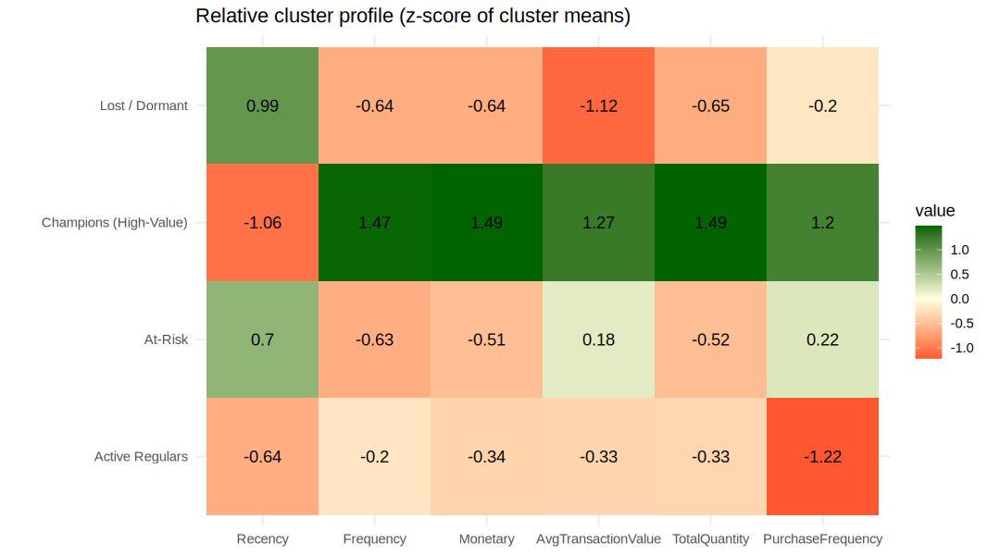

In [ ]:
# Rule-based segment names derived from cluster means
ord <- profile$KMeans_Cluster[order(-profile$Monetary)]
med_rec <- median(cust$Recency)
seg_names <- setNames(character(K), as.character(ord))
for (i in seq_along(ord)) {
  cl <- ord[i]
  seg_names[as.character(cl)] <-
    if (i == 1) "Champions (High-Value)"
    else if (i == K) "Lost / Dormant"
    else if (profile$Recency[profile$KMeans_Cluster == cl] <= med_rec) "Active Regulars"
    else "At-Risk"
}
cust$Segment <- seg_names[as.character(cust$KMeans_Cluster)]
print(seg_names)

# Heatmap of z-scored cluster means
rel <- profile[, cluster_features]
rel <- as.data.frame(scale(rel)); rel$Segment <- seg_names[as.character(profile$KMeans_Cluster)]
melt(rel, id.vars = "Segment") %>%
  ggplot(aes(variable, Segment, fill = value)) + geom_tile() +
  geom_text(aes(label = round(value, 2))) +
  scale_fill_gradient2(low = "red", mid = "lightyellow", high = "darkgreen") +
  labs(title = "Relative cluster profile (z-score of cluster means)", x = NULL, y = NULL) +
  theme_minimal()

## 9. High-Value Segment and Supervised Prediction

The high-value segment is the cluster with the highest mean Monetary value. The classifiers predict membership of this segment.

> **Data-leakage note:** the clusters were built from RFM-type features, so predicting them from the *same* features is nearly trivial. To make the task meaningful, the classifiers use behavioural features not used for clustering (unique products, tenure, cancellation rate, basket size) plus Recency, Frequency and PurchaseFrequency, and exclude Monetary-derived columns. Set `LEAKY <- TRUE` to see the inflated all-features result for comparison.

In [ ]:
hv_cluster <- profile$KMeans_Cluster[which.max(profile$Monetary)]
cust$HighValue <- factor(ifelse(cust$KMeans_Cluster == hv_cluster, 1, 0), levels = c(0, 1))
cat("High-value cluster:", hv_cluster, "| share:", round(mean(cust$HighValue == 1), 3), "\n")

LEAKY <- FALSE
pred_features <- if (LEAKY) {
  c(cluster_features, "UniqueProducts", "CancelRate", "TenureDays", "AvgBasketQty")
} else {
  c("Recency", "Frequency", "UniqueProducts", "TenureDays", "AvgBasketQty",
    "CancelRate", "PurchaseFrequency")
}

model_df <- log1p(pmax(as.data.frame(cust[, pred_features]), 0))
model_df$HighValue <- cust$HighValue

# Stratified 75/25 split
set.seed(42)
train_idx <- unlist(lapply(split(seq_len(nrow(model_df)), model_df$HighValue),
                           function(i) sample(i, floor(0.75 * length(i)))))
train <- model_df[train_idx, ]; test <- model_df[-train_idx, ]
table(train$HighValue); table(test$HighValue)

High-value cluster: 3 | share: 0.161 



   0    1 
2730  523 


  0   1 
910 175 

In [ ]:
# --- Random Forest ---
set.seed(42)
rf <- randomForest(HighValue ~ ., data = train, ntree = 300, importance = TRUE)
rf_prob <- predict(rf, test, type = "prob")[, "1"]
rf_pred <- predict(rf, test)

# --- SVM (RBF kernel; e1071 scales inputs internally) ---
set.seed(42)
svm_fit <- svm(HighValue ~ ., data = train, kernel = "radial", cost = 1,
               probability = TRUE, class.weights = c("0" = 1, "1" = 3))
svm_pred <- predict(svm_fit, test, probability = TRUE)
svm_prob <- attr(svm_pred, "probabilities")[, "1"]

metrics <- function(truth, pred, prob) {
  cm <- table(Predicted = pred, Actual = truth)
  tp <- cm["1", "1"]; fp <- cm["1", "0"]; fn <- cm["0", "1"]; tn <- cm["0", "0"]
  precision <- tp / (tp + fp); recall <- tp / (tp + fn)
  c(Accuracy = (tp + tn) / sum(cm), Precision = precision, Recall = recall,
    F1 = 2 * precision * recall / (precision + recall),
    ROC_AUC = as.numeric(auc(roc(truth, prob, quiet = TRUE))))
}

results <- rbind("Random Forest" = metrics(test$HighValue, rf_pred, rf_prob),
                 "SVM (RBF)"     = metrics(test$HighValue, svm_pred, svm_prob))
round(results, 4)

,Accuracy,Precision,Recall,F1,ROC_AUC
Random Forest,0.9742,0.9509,0.8857,0.9172,0.9957
SVM (RBF),0.9806,0.9529,0.9257,0.9391,0.9981


Random Forest
         Actual
Predicted   0   1
        0 902  20
        1   8 155

SVM (RBF)
         Actual
Predicted   0   1
        0 902  13
        1   8 162


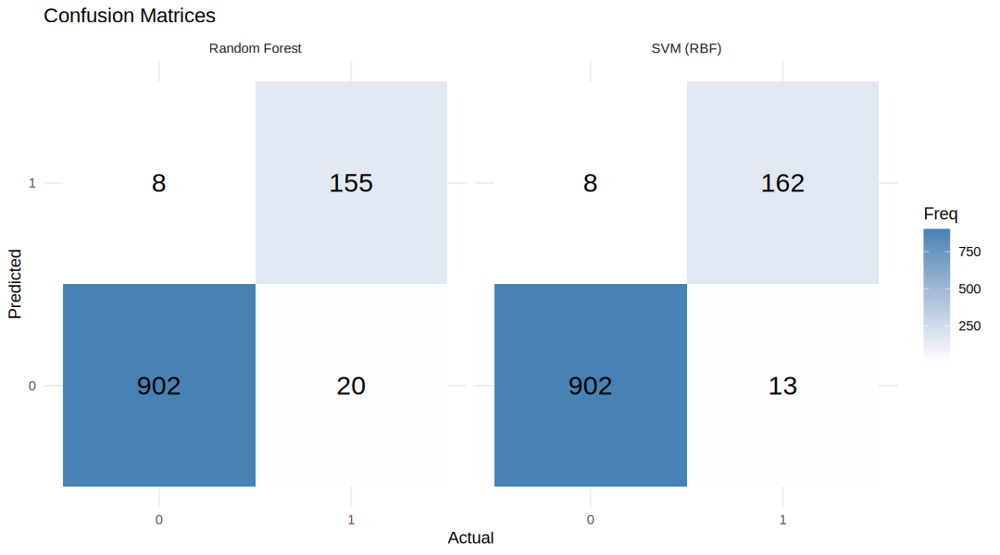

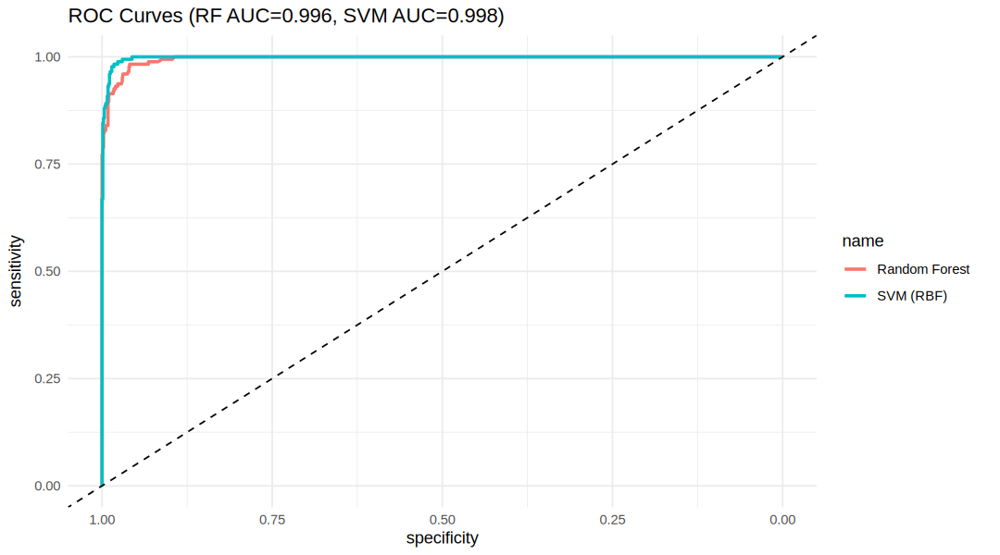

In [ ]:
# Confusion matrices
cat("Random Forest\n"); print(table(Predicted = rf_pred, Actual = test$HighValue))
cat("\nSVM (RBF)\n");  print(table(Predicted = svm_pred, Actual = test$HighValue))

cm_df <- rbind(
  transform(as.data.frame(table(Predicted = rf_pred,  Actual = test$HighValue)), Model = "Random Forest"),
  transform(as.data.frame(table(Predicted = svm_pred, Actual = test$HighValue)), Model = "SVM (RBF)"))
ggplot(cm_df, aes(Actual, Predicted, fill = Freq)) + geom_tile() +
  geom_text(aes(label = Freq), size = 6) + facet_wrap(~Model) +
  scale_fill_gradient(low = "white", high = "steelblue") +
  labs(title = "Confusion Matrices") + theme_minimal()

# ROC curves
roc_rf  <- roc(test$HighValue, rf_prob,  quiet = TRUE)
roc_svm <- roc(test$HighValue, svm_prob, quiet = TRUE)
ggroc(list(`Random Forest` = roc_rf, `SVM (RBF)` = roc_svm), linewidth = 1) +
  geom_abline(slope = 1, intercept = 1, linetype = "dashed") +
  labs(title = sprintf("ROC Curves (RF AUC=%.3f, SVM AUC=%.3f)", auc(roc_rf), auc(roc_svm))) +
  theme_minimal()

## 10. Feature Importance

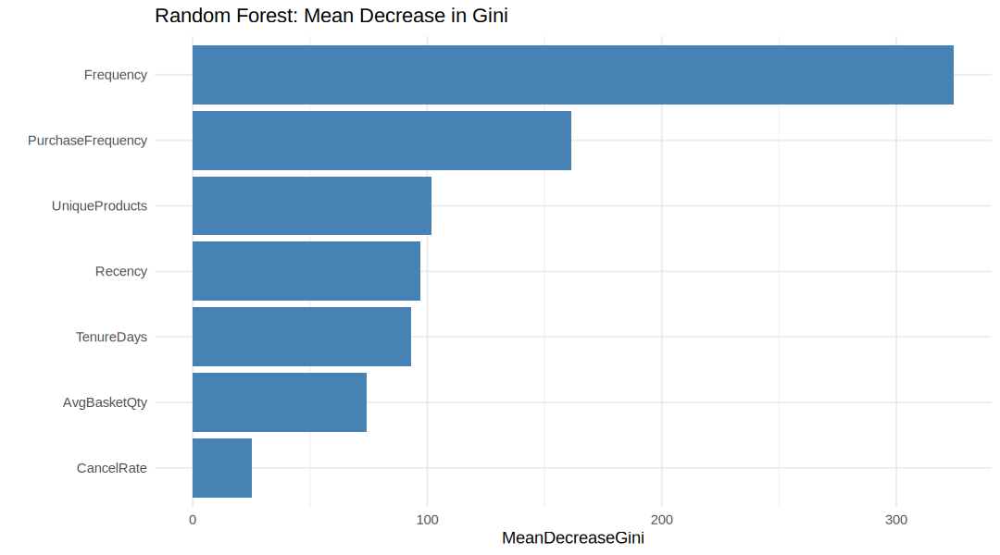

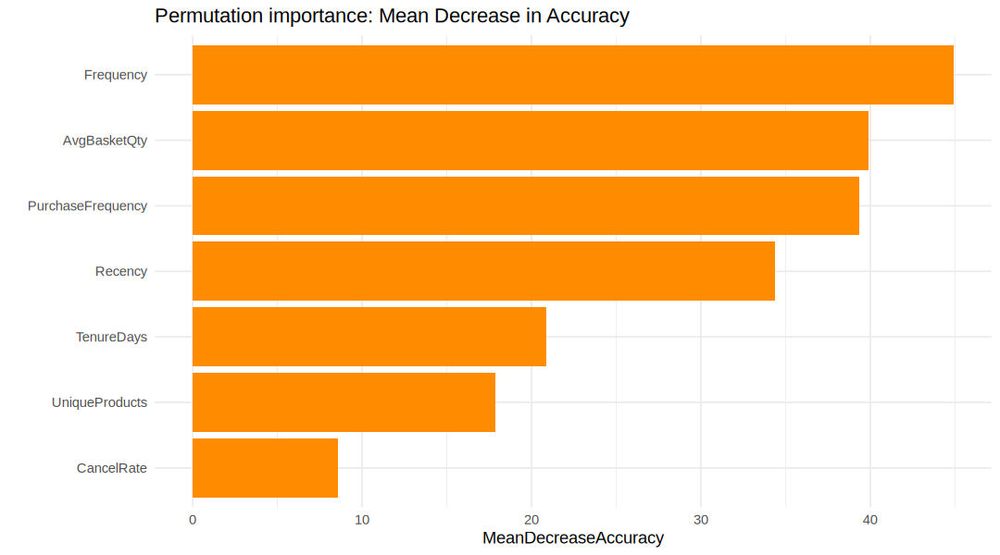

In [ ]:
imp <- as.data.frame(importance(rf)); imp$Feature <- rownames(imp)

p1 <- ggplot(imp, aes(reorder(Feature, MeanDecreaseGini), MeanDecreaseGini)) +
  geom_col(fill = "steelblue") + coord_flip() +
  labs(title = "Random Forest: Mean Decrease in Gini", x = NULL) + theme_minimal()
p2 <- ggplot(imp, aes(reorder(Feature, MeanDecreaseAccuracy), MeanDecreaseAccuracy)) +
  geom_col(fill = "darkorange") + coord_flip() +
  labs(title = "Permutation importance: Mean Decrease in Accuracy", x = NULL) + theme_minimal()
print(p1); print(p2)

## 11. Interactive 3D Visualisation (Plotly)

In [41]:
# pandoc is needed to create self-contained HTML (Colab usually has it; install if missing)
if (Sys.which("pandoc") == "") system("apt-get -qq update && apt-get -qq install -y pandoc")

library(plotly)
library(htmlwidgets)

show_plotly <- function(fig, file = "plot.html", height = 700) {
  saveWidget(fig, file, selfcontained = TRUE)
  html <- paste(readLines(file, warn = FALSE), collapse = "\n")
  html <- gsub("&", "&amp;", html, fixed = TRUE)
  html <- gsub("\"", "&quot;", html, fixed = TRUE)
  IRdisplay::display_html(
    sprintf('<iframe srcdoc="%s" width="100%%" height="%d" frameborder="0"></iframe>', html, height))
}

In [42]:
plot_df <- cust %>% mutate(log_Frequency = log1p(Frequency), log_Monetary = log1p(Monetary))

fig <- plot_ly(plot_df, x = ~Recency, y = ~log_Frequency, z = ~log_Monetary,
               color = ~Segment, type = "scatter3d", mode = "markers",
               marker = list(size = 3, opacity = 0.7),
               text = ~paste("Customer:", CustomerID, "<br>Frequency:", Frequency,
                             "<br>Monetary:", round(Monetary, 2)),
               hoverinfo = "text") %>%
  layout(title = "Customer Segments: Recency vs Frequency vs Monetary (log scale)",
         scene = list(xaxis = list(title = "Recency (days)"),
                      yaxis = list(title = "log(Frequency)"),
                      zaxis = list(title = "log(Monetary)")))

show_plotly(fig, "rfm_3d.html")

plotly

In [43]:
pc_df <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3], Segment = cust$Segment)

fig_pca <- plot_ly(pc_df, x = ~PC1, y = ~PC2, z = ~PC3, color = ~Segment,
                   type = "scatter3d", mode = "markers",
                   marker = list(size = 3, opacity = 0.7)) %>%
  layout(title = "3D PCA projection of customer segments")

show_plotly(fig_pca, "pca_3d.html")

plotly

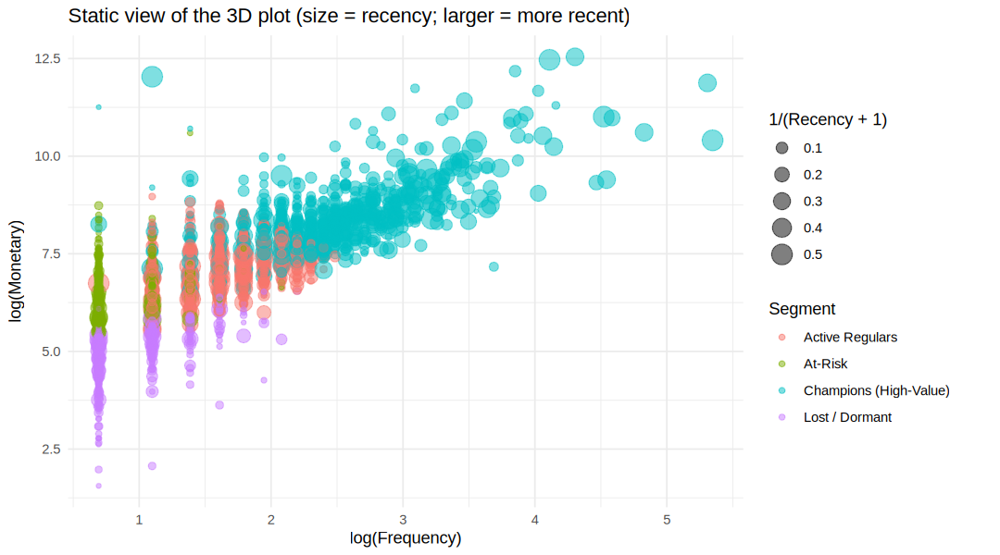

In [44]:
ggplot(plot_df, aes(log_Frequency, log_Monetary, colour = Segment, size = 1/(Recency + 1))) +
  geom_point(alpha = 0.5) +
  labs(title = "Static view of the 3D plot (size = recency; larger = more recent)",
       x = "log(Frequency)", y = "log(Monetary)") +
  theme_minimal()

## 12. Segment-wise Marketing Recommendations

In [ ]:
strategies <- c(
  "Champions (High-Value)" = "VIP/loyalty tier, early access to new products, personalised bundles, referral rewards. Protect margin: avoid heavy discounting.",
  "Active Regulars"        = "Cross-sell and upsell, volume/bundle offers, free-shipping thresholds, nudges to increase basket size and move them toward Champions.",
  "At-Risk"                = "Win-back emails/SMS, time-limited discounts, 'we miss you' campaigns, feedback surveys to find the cause of reduced activity.",
  "Lost / Dormant"         = "Low-cost reactivation (newsletter, seasonal promos), strong one-off incentive; suppress from expensive channels if there is no response."
)

summary_tbl <- profile %>%
  mutate(Segment = seg_names[as.character(KMeans_Cluster)]) %>%
  select(Segment, Customers, `% Customers`, `% Revenue`, Recency, Frequency, Monetary) %>%
  mutate(Strategy = strategies[Segment]) %>%
  arrange(desc(Monetary))
options(width = 200)
as.data.frame(summary_tbl)

Segment,Customers,% Customers,% Revenue,Recency,Frequency,Monetary,Strategy
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Champions (High-Value),698,16.1,79.0,20.30,13.74,8540.83,"VIP/loyalty tier, early access to new products, personalised bundles, referral rewards. Protect margin: avoid heavy discounting."
Active Regulars,1394,32.1,12.6,47.44,4.00,1361.39,"Cross-sell and upsell, volume/bundle offers, free-shipping thresholds, nudges to increase basket size and move them toward Champions."
At-Risk,1144,26.4,6.6,134.59,1.53,711.91,"Win-back emails/SMS, time-limited discounts, 'we miss you' campaigns, feedback surveys to find the cause of reduced activity."
Lost / Dormant,1102,25.4,1.8,153.73,1.47,193.74,"Low-cost reactivation (newsletter, seasonal promos), strong one-off incentive; suppress from expensive channels if there is no response."


## 13. Interpretation and Conclusion

*Fill in using your actual outputs:*

- **Optimal k:** the elbow and silhouette plots suggest k = ___ ; K-Means silhouette = ___ vs Hierarchical = ___ (ARI = ___).
- **Segments:** Champions are ___% of customers but contribute ___% of revenue; Dormant customers are ___%.
- **PCA:** the first two components explain ___% of variance, and the segments separate mainly along ___.
- **Models:** Random Forest vs SVM, ROC-AUC ___ vs ___; the most important predictors were ___.
- **Limitations:** clusters are unsupervised labels (not ground truth), the data covers about one year of one UK retailer, and the target is derived from the clustering itself.
- **Business takeaway:** prioritise retention of Champions, grow Active Regulars, and run low-cost reactivation for Dormant customers.